In [1]:
from pafi import PAFI 
from ase.calculators.eam import EAM
from ase.io import read
import numpy as np

In [2]:
# Check if LAMMPSlib is available, otherwise fall back to EAM calculator
eam_path = 'neb_paths/W.eam.fs'
element = 'W'
try:
    from ase.calculators.lammpslib import LAMMPSlib
    lmpcmds = [ "pair_style eam/fs",
            f"pair_coeff * * {eam_path} {element}"]
    calc = LAMMPSlib(lmpcmds=lmpcmds,atom_types={element: 1}, keep_alive=True)
    print("LAMMPSlib is available.")
except ImportError:
    calc = EAM(potential=eam_path)
    print("Falling back to EAM calculator SLOW.")

LAMMPSlib is available.


Read NEB trajectory and test interpolation

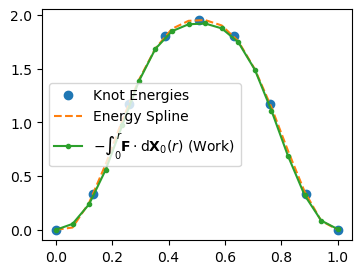

In [3]:
images = read('neb_paths/w-vac-path.traj',index=":")
pafi = PAFI(images, calc)
pafi.plot_neb()

Perform sampling on each hyperplane

**NB: inadequate number of samples here!!**
As can be seen by the fact that virialT is wrong...

In [4]:
r_array = np.linspace(0.0,1.0,9)
pafi.reset_data()

for r in r_array:
    pafi.run(r,T=0.0,nsteps=1,thermsteps=1,verbose=False)
    pafi.run(r,T=300.0,nsteps=201,thermsteps=200,print_nevery=200,verbose=True);

Thermalisation over 200 steps took 0.77s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.00    265.36  0.95    1.12    -0.00   0.18    0.000 s
200     0.00    321.88  0.12    1.00    -0.00   0.19    0.000 s
Thermalisation over 200 steps took 0.69s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.12    235.74  -4.27   1.12    0.00    0.14    0.000 s
200     0.12    296.61  -4.62   1.12    0.00    0.20    0.000 s
Thermalisation over 200 steps took 0.63s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.25    236.07  -7.35   1.01    -0.00   0.19    0.000 s
200     0.25    292.21  -7.17   1.03    -0.00   0.18    0.000 s
Thermalisation over 200 steps took 0.62s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.38    228.28  -2.33   1.00    -0.00   0.16    0.000 s
200     0.38    289.38  -3.03   1.08    -0.00   0.19    0.000 s
Thermalisation over 200 steps took 0.69s
Step    r       T       dF     

**Plot data**

Error bars are obtained via naive blocking analysis of data

9 data points for T = 0
1809 data points for T = 300


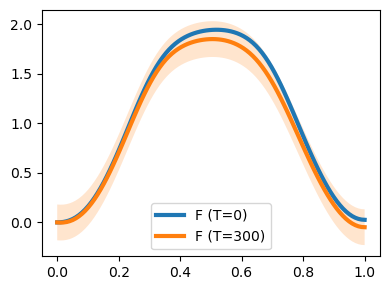

9 data points for T = 0
1809 data points for T = 300


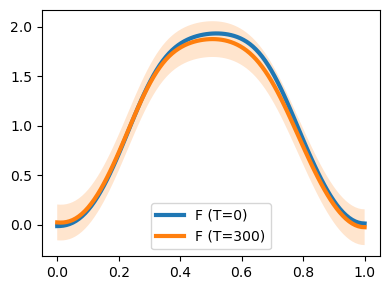

In [5]:
pafi.plot_data(symmetric=False);

# as we know initial and final are the same state modulo symmetries
pafi.plot_data(symmetric=True); 

Add some more data

In [6]:
for r in r_array:
    pafi.run(r,T=300.0,nsteps=101,thermsteps=200,print_nevery=200,verbose=True);

Thermalisation over 200 steps took 0.66s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.00    254.92  -0.23   0.97    -0.00   0.16    0.000 s
Thermalisation over 200 steps took 0.68s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.12    232.01  -3.99   1.01    -0.00   0.17    0.000 s
Thermalisation over 200 steps took 0.65s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.25    240.27  -7.19   1.04    0.00    0.15    0.000 s
Thermalisation over 200 steps took 0.73s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.38    245.83  -2.98   1.06    -0.00   0.16    0.000 s
Thermalisation over 200 steps took 0.68s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.50    229.88  -0.02   1.13    -0.00   0.19    0.000 s
Thermalisation over 200 steps took 0.64s
Step    r       T       dF      Psi     dx.t    max(dx) dt    
0       0.62    261.02  2.20    0.97    -0.00   0.19    

9 data points for T = 0
2718 data points for T = 300


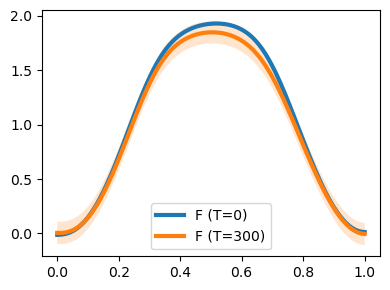

In [7]:
pafi.plot_data(symmetric=True);